<div style="
    border: 2px solid #2c3e50;
    border-radius: 12px;
    padding: 20px;
    background-color: #f8f9fa;
    margin: 10px 0 20px 0;
    box-shadow: 0 2px 8px rgba(0,0,0,0.08);
">

  <h1 style="margin: 0; color: #1f3b73; font-size: 28px;">
    Notebook 06 — Sensitivity Analysis
  </h1>

  <h2 style="margin: 10px 0 18px 0; color: #34495e; font-size: 20px; font-weight: normal;">
    Python for Operations Research
  </h2>

  <hr style="border: none; border-top: 1px solid #cfd8dc; margin: 15px 0;">

  <p style="margin: 6px 0; font-size: 16px;">
    <b>Amirkabir University of Technology (Tehran Polytechnic)</b>
  </p>

  <p style="margin: 6px 0; font-size: 15px;">
    <b>Prof:</b> Dr. A. Golroo
  </p>

  <p style="margin: 6px 0; font-size: 15px;">
    <b>Mentor:</b> Parsa Sadri
  </p>

</div>


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    0. Problem Definition
  </h2>
</div>

In optimization models we usually assume that all parameters are known exactly.

However, in real-world problems parameters often change:

- profits change
- resource availability changes
- costs fluctuate

Therefore an important question arises:

> How sensitive is the optimal solution to changes in model parameters?

This is the goal of **Sensitivity Analysis**.

In this notebook we will learn:

1. What sensitivity analysis means
2. Range of feasibility
3. Range of optimality
4. Relationship with shadow prices
5. Visual interpretation using plots


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    1. Base Optimization Model
  </h2>
</div>

We start with the same production problem used in previous notebooks.

A factory produces two products.

Profit:

$$Product A → 30$$  
$$Product B → 20$$

Constraints:

Machine time:

$$2A + B ≤ 100$$

Material:

$$A + B ≤ 80$$

Decision variables:

A = units of product A  
B = units of product B


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    2. Solve the Base Model
  </h2>
</div>

In [2]:
import pulp
import numpy as np
import matplotlib.pyplot as plt

In [3]:
model = pulp.LpProblem("Production", pulp.LpMaximize)

A = pulp.LpVariable("A", lowBound=0)
B = pulp.LpVariable("B", lowBound=0)

model += 30*A + 20*B

model += 2*A + B <= 100
model += A + B <= 80

model.solve()

print("Optimal production")

print("A =", A.varValue)
print("B =", B.varValue)

print("Optimal profit =", pulp.value(model.objective))


Optimal production
A = 20.0
B = 60.0
Optimal profit = 1800.0


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    3. Range of Feasibility
  </h2>
</div>

The **Range of Feasibility** refers to the range in which the RHS of a constraint can change **without changing the shadow price**.

Example:

Machine constraint:

$$2A + B ≤ 100$$

If we increase machine capacity slightly:

$$100 → 105 → 110$$

The optimal solution may change smoothly.

But at some point another constraint becomes binding and the behavior changes.

This boundary defines the **range of feasibility**.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    4. Profit vs Machine Capacity
  </h2>
</div>

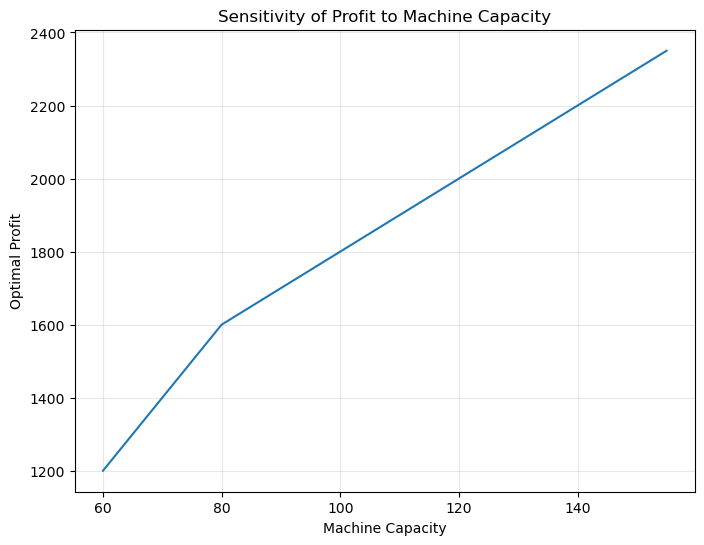

In [4]:
capacities = np.arange(60,160,5)

profits = []

for cap in capacities:

    model = pulp.LpProblem("Production", pulp.LpMaximize)

    A = pulp.LpVariable("A", lowBound=0)
    B = pulp.LpVariable("B", lowBound=0)

    model += 30*A + 20*B

    model += 2*A + B <= cap
    model += A + B <= 80

    model.solve()

    profits.append(pulp.value(model.objective))

plt.figure(figsize=(8,6))

plt.plot(capacities, profits)

plt.xlabel("Machine Capacity")
plt.ylabel("Optimal Profit")

plt.title("Sensitivity of Profit to Machine Capacity")

plt.grid(alpha=0.3)

plt.show()


Interpretation:

Notice that the curve is **piecewise linear**.

Within a certain interval the slope is constant.

That slope equals the **shadow price**.

When the slope changes, the **binding constraint structure changes**.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    5. How Production Changes with Capacity
  </h2>
</div>

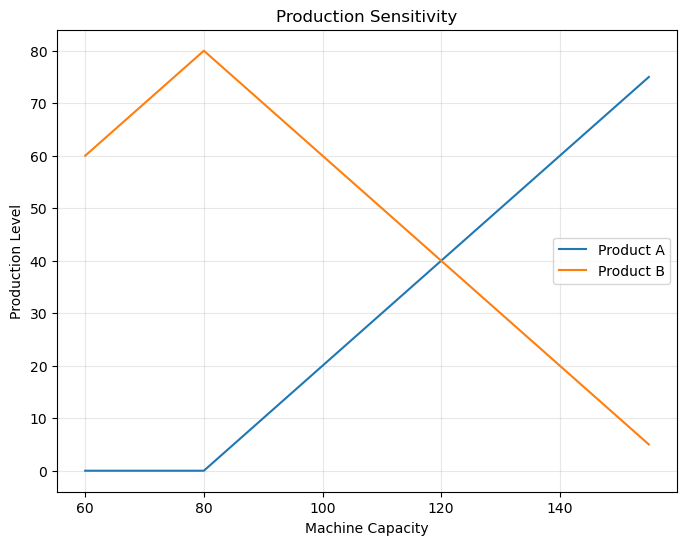

In [5]:
A_values = []
B_values = []

for cap in capacities:

    model = pulp.LpProblem("Production", pulp.LpMaximize)

    A = pulp.LpVariable("A", lowBound=0)
    B = pulp.LpVariable("B", lowBound=0)

    model += 30*A + 20*B

    model += 2*A + B <= cap
    model += A + B <= 80

    model.solve()

    A_values.append(A.varValue)
    B_values.append(B.varValue)

plt.figure(figsize=(8,6))

plt.plot(capacities, A_values,label="Product A")
plt.plot(capacities, B_values,label="Product B")

plt.xlabel("Machine Capacity")
plt.ylabel("Production Level")

plt.title("Production Sensitivity")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

This visualization shows how the **optimal production plan changes when resources change**.

Sometimes the optimal solution remains stable.

Sometimes the production mix changes dramatically.

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    6. Range of Optimality
  </h2>
</div>

Range of optimality refers to the interval in which the **objective function coefficients** can change without changing the optimal basis.

Example:

Profit of product A:

$$30$$

Suppose market conditions change:

$$25 → 30 → 35 → 40$$

Will the optimal solution change?


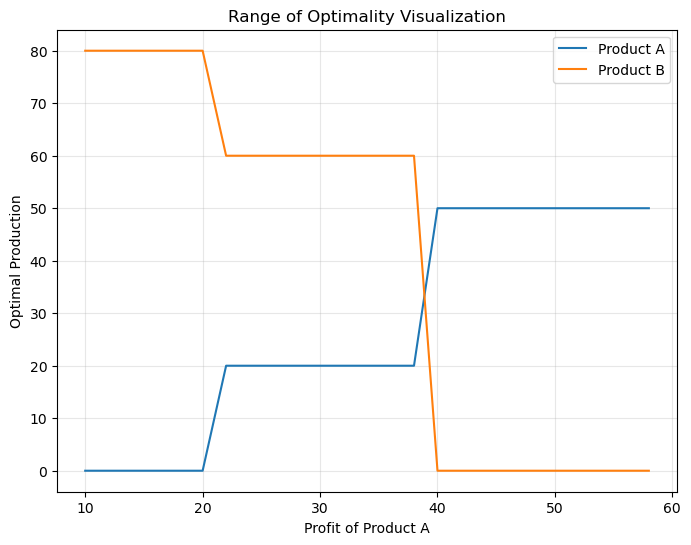

In [6]:
profits_A = np.arange(10,60,2)

opt_A = []
opt_B = []

for pA in profits_A:

    model = pulp.LpProblem("Production", pulp.LpMaximize)

    A = pulp.LpVariable("A", lowBound=0)
    B = pulp.LpVariable("B", lowBound=0)

    model += pA*A + 20*B

    model += 2*A + B <= 100
    model += A + B <= 80

    model.solve()

    opt_A.append(A.varValue)
    opt_B.append(B.varValue)

plt.figure(figsize=(8,6))

plt.plot(profits_A,opt_A,label="Product A")
plt.plot(profits_A,opt_B,label="Product B")

plt.xlabel("Profit of Product A")
plt.ylabel("Optimal Production")

plt.title("Range of Optimality Visualization")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

Interpretation:

When the profit coefficient changes within a certain interval, the optimal solution remains unchanged.

Outside that range, the optimal basis changes.

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    7. Visualizing the Feasible Region
  </h2>
</div>

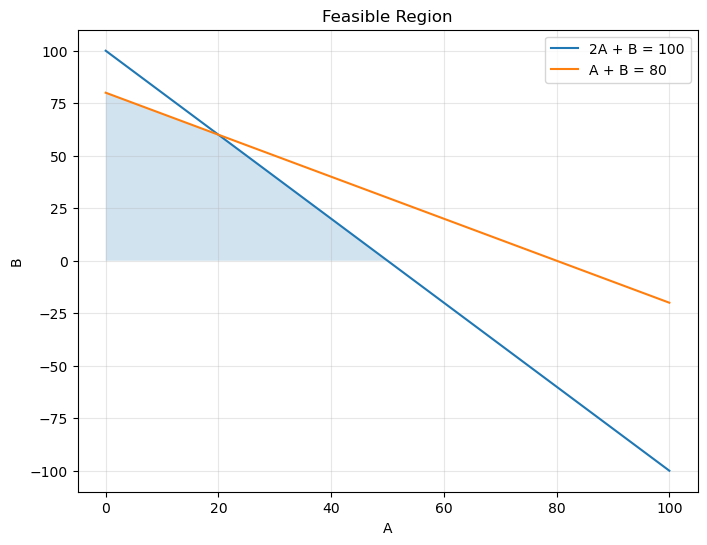

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0,100,400)

machine = 100 - 2*x
material = 80 - x

plt.figure(figsize=(8,6))

plt.plot(x, machine, label="2A + B = 100")
plt.plot(x, material, label="A + B = 80")

y = np.minimum(machine, material)

plt.fill_between(x, y, 0, where=(y>=0), alpha=0.2)

plt.xlabel("A")
plt.ylabel("B")

plt.title("Feasible Region")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


The optimal solution lies on a **vertex of the feasible region**.

Sensitivity analysis studies how this vertex changes when parameters change.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    8. Managerial Interpretation
  </h2>
</div>

Sensitivity analysis helps decision makers answer questions such as:

- How valuable is an additional unit of capacity?
- Which parameter changes would affect the optimal plan?
- How robust is the solution?

Managers often use sensitivity analysis to decide:

- capacity expansion
- pricing strategies
- investment decisions


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    9. Exercises
  </h2>
</div>

### Exercise 1

Plot profit vs material capacity.

Compare the slope with the shadow price of the material constraint.

---

### Exercise 2

Change profit of product B from:

20 → 10

Does the optimal solution change?

---

### Exercise 3

Increase machine capacity gradually.

At what point does the optimal production mix change?

---

### Exercise 4 (Visualization Challenge)

Create a **3D plot** where:

x-axis → machine capacity  
y-axis → material capacity  
z-axis → optimal profit

Interpret the results.
